In [1]:
%pip install numpy
%pip install matplotlib
%pip install imageio

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [4]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
max_steps_in_env = 20 # used for episodic evaluation


In [5]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
s = env.reset() # prepared clean environment

num_states = num_rows * num_cols # number of unique states
V = np.zeros(num_states) # initialization for V(s)

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
# try looking at these functions' docs for inspiration

# Pseudokod:
# initialization V(x) for all x \in X
# Repeat:
#     Delta <- 0;
#     for x in X:
#         V <- V(x);
#         V(x) <- \max_a \sum_{y,r} p(y,r|x,a)[r + gamma*V(y)];
#         Delta <- max(Delta, abs(V - V(x)));
#     end;
# until Delta < theta;

for k in range(max_number_iterations):
    delta = 0
    
    for x in range(num_states):
        if env.is_terminal_state(x):
            continue
        
        v = V[x]
        
        max_action_value = float('-inf')
        for a in ACTIONS:
            transitions = env.get_transition_distribution(x, a)
            
            action_value = 0
            for prob, y in transitions:
                r = env.reward(x, a, y)
                # if env.is_terminal_state(y):
                    # r -= goal_reward
                action_value += prob * (r + gamma * V[y])

            max_action_value = max(max_action_value, action_value)
        
        V[x] = max_action_value
        delta = max(delta, abs(v - V[x])) 
    
    if k == max_number_iterations - 1:
        print("Osiągnięto maksymalną liczbę iteracji")
        break

    if delta < threshold:  
        print(f"Zbieżność po {k+1} iteracjach")
        break

# fix na gradient
# V[env.row_column_to_state(*goal_state)] = env.goal_reward

Zbieżność po 24 iteracjach


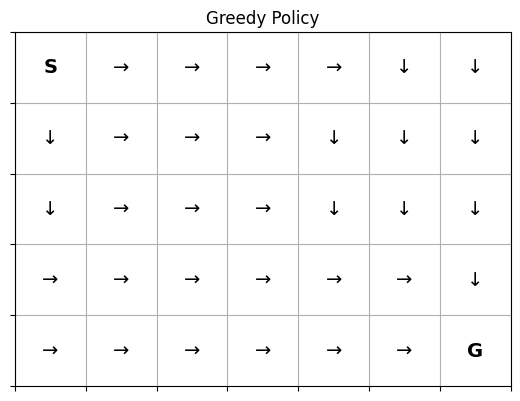

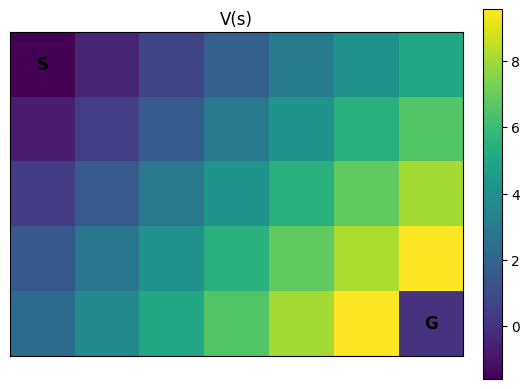

{'avg_return': -0.92, 'std_return': 1.9271, 'success_rate': 1.0, 'avg_steps': 11.92}


In [6]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# retrieve policy from V(s)
pi = greedy_policy_from_V(V, env, gamma)

# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes 
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

Zaimplementować:
- algorytm Q-learning
- eksplorację epsilon-greedy
- wyznaczanie polityki zachłannej na podstawie wartości Q

In [7]:
# pseudokod:
# init Q(x,a);
# Q(terminalState, _) = 0;
# For each episode:
#   init X;
#   For each step of episode:
#     choose A from X using policy derived from Q (eps-greedy);
#     take action A, observe R and X';
#     Q(X,A) <- Q(X,A) + alpha*[R + gamma*max_a(Q(X',a)) - Q(X,A)];
#     X <- X';
#     if(X is terminal):
#       break;

In [8]:
num_episodes = 10000
alpha = 0.3
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.95

np.random.seed = random_seed

def epsilon_greedy(Q, state, epsilon):
    if np.random.random() < epsilon:
        return np.random.choice(ACTIONS)
    else:
        return int(np.argmax(Q[state]))

# ----- Q-learning -----

# init Q(x,a);
Q = np.zeros((num_states, len(ACTIONS)))

# Q(terminalState, _) = 0;
goal_state_int = env.row_column_to_state(*goal_state)
Q[goal_state_int, :] = 0.0

for episode in range(num_episodes):
    # init X;
    X = env.reset()
    done = False

    while not done:
        # choose A from X using policy derived from Q (eps-greedy);
        A = epsilon_greedy(Q, X, epsilon)

        # take action A, observe R and X';
        X_next, R, done, info = env.step(A)

        # Q(X,A) <- Q(X,A) + alpha*[R + gamma*max_a(Q(X',a)) - Q(X,A)];
        max_a_Q = 0.0 if env.is_terminal_state(X_next) else np.max(Q[X_next])
        Q[X, A] += alpha * (R + gamma * max_a_Q - Q[X, A])

        # X <- X'
        X = X_next  

        if env.is_terminal_state(X):
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

# fix na gradient
# Q[goal_state_int, :] = env.goal_reward

print(f"Trening zakończony. Końcowe epsilon: {epsilon:.4f}")

Trening zakończony. Końcowe epsilon: 0.0500


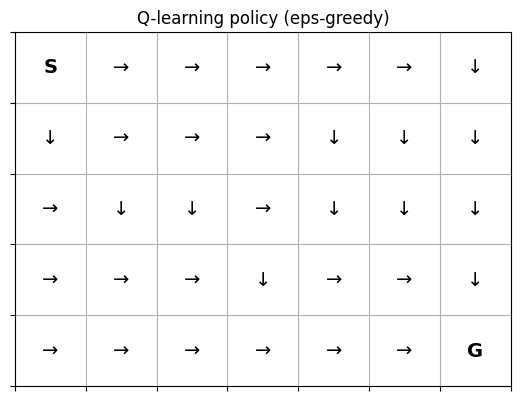

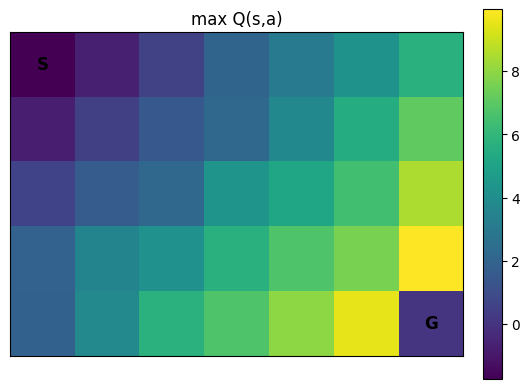

{'avg_return': -1.18, 'std_return': 2.0561, 'success_rate': 1.0, 'avg_steps': 12.18}


In [9]:
policy_plot_name = "policy_Q.png"
value_plot_name = "value_Q.png"
gif_name = "episode_Q.gif"
n_val_episodes = 50

pi_Q = np.argmax(Q, axis=1)
value = np.max(Q, axis=1)

plot_policy(env, pi_Q, filename=policy_plot_name, title="Q-learning policy (eps-greedy)")
plot_value_heatmap(env, value, filename=value_plot_name, title="max Q(s,a)")
metrics_Q = evaluate(env, Q=Q, n_episodes=n_val_episodes, seed=random_seed)
print(metrics_Q)
run_to_gif(env, Q=Q, gif_path=gif_name, fps=6)